# Load the library

In [ ]:
from signed_module_partition import *

# Load an example network

In [41]:
# Example graph for module partition
session = '797828357'
stimulus = 'spontaneous'
G = load_graphs(directory='./files/adjacency_matrices', session=session, stimulus=stimulus, weight=True)
print(G)

DiGraph with 240 nodes and 336 edges


# Calculate signed module partition for real network

In [29]:
# Calculate signed modularity across different resolution parameters for multiple repeats
resolution_list = np.arange(0, 2.1, 0.1).round(2)
weight = 'weight'
all_comms, sModularity = get_comms_sModularity(G, resolution_list=resolution_list, num_repeat=10, weight=weight, cc=False)

100%|██████████| 4410/4410 [01:18<00:00, 56.21it/s]


In [30]:
# Combine clustering results and get one combined clustering across multiple repeats for each resolution parameter pair, recalculate signed modularity
all_combined_comms, all_combined_sModularity = {pos_resolution: {} for pos_resolution in resolution_list}, np.zeros((len(resolution_list), len(resolution_list)))
for p_ind, pos_resolution in enumerate(resolution_list):
	for n_ind, neg_resolution in enumerate(resolution_list):
		comms_list = all_comms[pos_resolution][neg_resolution]
		combined_comms = combine_clustering_results(comms_list)
		all_combined_comms[pos_resolution][neg_resolution] = combined_comms
		all_combined_sModularity[p_ind, n_ind] = signed_modularity(G.copy(), communities=combined_comms, weight=weight, pos_resolution=pos_resolution, neg_resolution=neg_resolution)

# Calculate signed module partition for null models

## Generate random networks with various reference models

In [ ]:
model_choices = ['erdos_renyi', 'degree_preserving', 'pair_preserving', 'signed_pair_preserving']
input_G = G
num_rewire = 200
model = model_choices[3]
# weight = 'weight' # connection strength (jitter-corrected CCG), can also be 'confidence' for Z score of jitter-corrected CCG in the example graph. Use your own edge weight for your graph.
cc = False
Q = 100
parallel = True # Set to True if you want to use multiprocessing to generate random graphs in parallel.
num_cores = 23

random_graphs = random_graph_generator(input_G=input_G, num_rewire=num_rewire, model=model, weight=weight, cc=cc, Q=Q, parallel=parallel, num_cores=num_cores, disable=False)

100%|██████████| 20/20 [00:00<00:00, 19549.31it/s]


## Test if random networks are properly generated

In [32]:
# Just for vefication purpose, this part can be skipped.
verify_random_graphs(G, random_graphs, model, weight=weight)

******Property verification for the generated random graphs using signed_pair_preserving model******
Number of nodes/edges and density test...


100%|██████████| 20/20 [00:00<00:00, 8601.94it/s]


Sum of edge weights test...


100%|██████████| 20/20 [00:00<00:00, 1768.41it/s]


Degree distribution test...


...

Pair distribution test...


100%|██████████| 20/20 [00:00<00:00, 26.55it/s]


Signed pair distribution test...


100%|██████████| 20/20 [00:00<00:00, 51.87it/s]

******All tests are passed!******


## Signed module partition

In [33]:
# Calculate signed modularity across different resolution parameters for multiple repeats
all_comms_null, sModularity_null = get_comms_sModularity_null(random_graphs, resolution_list=resolution_list, num_repeat=2, weight=weight, cc=False, parallel=True, num_cores=23, disable=False) # fewer repeats for efficiency

100%|██████████| 20/20 [00:00<00:00, 28581.29it/s]


## Combine clustering results from multiple runs

In [34]:
# Combine clustering results and get one combined clustering across multiple repeats for each resolution parameter pair, recalculate signed modularity
all_combined_sModularity_null = np.zeros((num_rewire, len(resolution_list), len(resolution_list)))
all_combinations = [(rewire_ind, all_comms, p_ind, pos_resolution, n_ind, neg_resolution) for rewire_ind, all_comms in enumerate(all_comms_null) for p_ind, pos_resolution in enumerate(resolution_list) for n_ind, neg_resolution in enumerate(resolution_list)]
for rewire_ind, all_comms, p_ind, pos_resolution, n_ind, neg_resolution in tqdm(all_combinations, disable=False):
	comms_list = all_comms[pos_resolution][neg_resolution]
	combined_comms = combine_clustering_results(comms_list)
	all_combined_sModularity_null[rewire_ind, p_ind, n_ind] = signed_modularity(random_graphs[rewire_ind].copy(), communities=combined_comms, weight=weight, pos_resolution=pos_resolution, neg_resolution=neg_resolution)

100%|██████████| 8820/8820 [01:09<00:00, 126.74it/s]


# Determine optimal resolution parameters

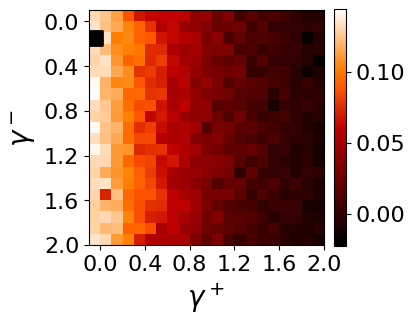

The optimal resolution parameters are gamma+=0.0, gamma-=0.2.


In [63]:
########################### visualize the delta_Q obtained from delta_H, resolution heatmap
def plot_sModularity_diff(real_Q, subs_Q, resolution_list):
	fig, ax = plt.subplots(1, 1, figsize=(4.2, 3.8), tight_layout=True)
	heatmap = (real_Q - subs_Q).T
	im = ax.imshow(heatmap, cmap="gist_heat") #, norm=divnorm
	max_index = np.unravel_index(heatmap.argmax(), heatmap.shape)
	# highlight the maximum point with a red circle
	ax.scatter(max_index[1], max_index[0], s=100, edgecolors='k', marker='s', facecolors='k', linewidths=2)
	cbar = plt.colorbar(im, ax=ax,fraction=0.046, pad=0.04)
	cbar.ax.tick_params(labelsize=16)
	ax.set_xticks(.5 + np.arange(0, len(resolution_list), 4))
	ax.set_xticklabels(labels=resolution_list[::4], fontsize=16)
	ax.set_yticks(.5 + np.arange(0, len(resolution_list), 4))
	ax.set_yticklabels(labels=resolution_list[::4], fontsize=16)
	ax.set_xlabel(r'$\gamma^+$', fontsize=20,color='k') #, weight='bold'
	ax.set_ylabel(r'$\gamma^-$', fontsize=20,color='k') #, weight='bold'
	# ax.invert_yaxis()
	plt.show()
	return resolution_list[max_index[1]], resolution_list[max_index[0]]
	
# # Use results averaged over multiple repeats
# pos_gamma, neg_gamma = plot_sModularity_diff(sModularity.mean(axis=-1), sModularity_null.mean(axis=(0,3)), resolution_list)
# print(f'The optimal resolution parameters are gamma+={pos_gamma}, gamma-={neg_gamma}.')
# # Combine results across multiple repeats for real network
# pos_gamma, neg_gamma = plot_sModularity_diff(all_combined_sModularity, sModularity_null.mean(axis=(0,3)), resolution_list)
# print(f'The optimal resolution parameters are gamma+={pos_gamma}, gamma-={neg_gamma}.')
# # Combine results across multiple repeats for random networks
# pos_gamma, neg_gamma = plot_sModularity_diff(sModularity.mean(axis=-1), all_combined_sModularity_null.mean(axis=0), resolution_list)
# print(f'The optimal resolution parameters are gamma+={pos_gamma}, gamma-={neg_gamma}.')
# Combine results across multiple repeats for both real network and random networks
pos_gamma, neg_gamma = plot_sModularity_diff(all_combined_sModularity, all_combined_sModularity_null.mean(axis=0), resolution_list)
print(f'The optimal resolution parameters are gamma+={pos_gamma}, gamma-={neg_gamma}.')

# Plot module parition with optimal resolution parameters

Number of communities 5, number of nodes: 94


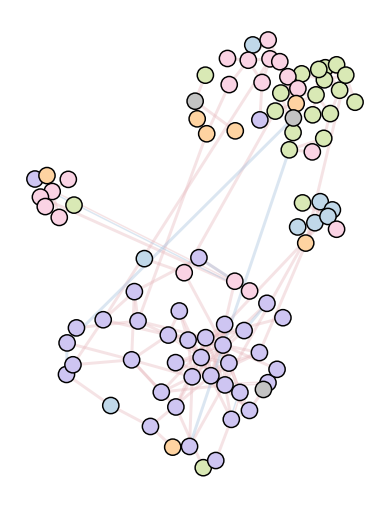

In [ ]:
def comm2label(comms):
  return [p for n, p in sorted({n:comms.index(comm) for comm in comms for n in comm}.items(), key=lambda x:x[0])]

def comm2partition(comms):
  return dict(sorted({node:comms.index(comm) for comm in comms for node in comm}.items(), key=lambda x:x[0]))

############ find nodes and comms with at least one between community edge
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in sublist]

def get_unique_elements(nested_list):
    return list(set(flatten_list(nested_list)))

def _find_between_community_edges(edges, node_to_community):
  """Convert the graph into a weighted network of communities."""
  between_community_edges = dict()
  for (ni, nj) in edges:
      if (ni in node_to_community) and (nj in node_to_community):
          ci = node_to_community[ni]
          cj = node_to_community[nj]
          if ci != cj:
              if (ci, cj) in between_community_edges:
                  between_community_edges[(ci, cj)] += 1
              elif (cj, ci) in between_community_edges:
                  # only compute the undirected graph
                  between_community_edges[(cj, ci)] += 1
              else:
                  between_community_edges[(ci, cj)] = 1

  return between_community_edges

def plot_graph_community(G, raw_node_areas, comms, th = 6):
	seed = 123
	np.random.seed(seed)
	fig, ax = plt.subplots(1, 1, figsize=(4, 6))
	# only plot large communities th>=6 for visualization
	node_areas = {ind:v for ind, (k,v) in enumerate(active_area_dict[session].items())}
	nx.set_node_attributes(G, node_areas, "area")
	comms = [comm for comm in comms if len(comm)>=th] # only plot large communities
	node_to_community = comm2partition(comms)
	between_community_edges = _find_between_community_edges(G.edges(), node_to_community)
	comms2plot = get_unique_elements(between_community_edges.keys())
	nodes2plot = [node for node in node_to_community if node_to_community[node] in comms2plot]
	node_color = {node:region_colors[visual_regions.index(G.nodes[node]['area'])] for node in nodes2plot}
	print('Number of communities {}, number of nodes: {}'.format(len(comms2plot), len(nodes2plot)))
	if len(nodes2plot):
		edge_colors = [transparent_rgb(colors.to_rgb('#2166ac'), [1,1,1], alpha=.4), transparent_rgb(colors.to_rgb('#b2182b'), [1,1,1], alpha=.3)] # blue and red
		# return G.subgraph(nodes2plot)
		G2plot = G.subgraph(nodes2plot).copy()
		for n1, n2, d in G2plot.edges(data=True):
			for att in ['confidence']:
				d.pop(att, None)
		# binary weight
		for edge in G2plot.edges():
			if G2plot[edge[0]][edge[1]]['weight'] > 0:
				G2plot[edge[0]][edge[1]]['weight'] = 1
			else:
				G2plot[edge[0]][edge[1]]['weight'] = -1
		# node_labels = {node:node_to_community[node] for node in nodes2plot}
		origin, scale, node_origin, node_scale=(-1, -1), (.9, .9), np.array([-1., -1.]), np.array([2., 2.])
		Graph(G2plot, nodes=nodes2plot, edge_cmap=colors.LinearSegmentedColormap.from_list("", edge_colors),
					node_color=node_color, node_edge_width=0.5, node_alpha=1., edge_alpha=0.4,
					node_layout='community', node_layout_kwargs=dict(node_to_community={node: comm for node, comm in node_to_community.items() if node in nodes2plot}),
					edge_layout='straight', edge_layout_kwargs=dict(k=1), node_edge_color='k',
					origin=origin, scale=scale, node_origin=node_origin, node_scale=node_scale, ax=ax) # bundled, node_labels=node_labels
	plt.tight_layout()
	plt.show()
 
a_file = open('./files/active_area_dict.pkl', 'rb')
active_area_dict = pickle.load(a_file)
a_file.close()
plot_graph_community(G, active_area_dict[session], all_combined_comms[pos_gamma][neg_gamma])